### Import Modules

In [138]:
import pandas as pd,numpy as np,json
from sklearn.metrics.pairwise import cosine_distances
import getpass,os
from langchain.chat_models import init_chat_model
from ai_patterns_mining import parse_json_safe,Config
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from time import time
from langchain.tools import tool
from pydantic import BaseModel, Field
import seaborn as sns
import matplotlib.pyplot as plt
from langchain.agents.structured_output import ToolStrategy

### Load Data

In [6]:
predicted_clusters = pd.read_csv("./predictions/predicted_clusters_v2.csv")
pattern_summaries = json.load(open("/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/outputs/prompt & rag/20251028_085918 - Run /extracted_patterns/pattern_summaries.json"))

In [20]:
predicted_clusters.head()

,Predicted Cluster Label,code_file
0,Explainable AI (XAI) Techniques,3DOD_thesis/cluster_0.py
1,Explainable AI (XAI) Techniques,3DOD_thesis/cluster_1.py
2,Explainable AI (XAI) Techniques,3DOD_thesis/cluster_10.py
3,Retrieval Augmented Generation(RAG) Optimizati...,3DOD_thesis/cluster_2.py
4,LLM Code Execution for Precision,3DOD_thesis/cluster_3.py


In [19]:
pattern_summaries = {pattern['cluster_id']: pattern['pattern_summary'] for pattern in pattern_summaries}

### Setup llm

In [78]:
if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter API key for Google Gemini: ")

llm = init_chat_model("gemini-2.5-flash", model_provider="google_genai", temperature=0)

# @tool
def verify_classifier(pattern_summaries, code_snippet, assigned_label):
    """Verify if the assigned label for the code snippet is correct based on pattern summaries."""
    prompt_template = """\
    Verify if the assigned pattern cluster label for the given code snippet is accurate based on the provided pattern summaries.
    * Dont consider about the pattern name of pattern summaries. Focus on the description and characteristics.
    Here are the pattern summaries for reference:
    {pattern_summaries}

    Code Snippet:
    {code_snippet}

    Assigned Cluster Label: {assigned_label}
    """
    return prompt_template.format(
        pattern_summaries=pattern_summaries,
        code_snippet=code_snippet,
        assigned_label=assigned_label
    )

class VerificationResponse(BaseModel):
    is_correct: bool = Field(..., description="Indicates whether the assigned label is correct.")
    score: int = Field(None, description="Score from 1 to 10 indicating the confidence level of the verification.")
    explanation: str = Field(..., description="Explanation for the verification decision. Max 80 words.")

verification_agent = create_agent(
    llm,
    # tools=[verify_classifier],
    system_prompt="You are an Exper AI Pattern Classifier Verifier. Your task is to verify if the assigned pattern cluster label for a given code snippet is accurate based on the provided pattern summaries.",
    response_format=ToolStrategy(VerificationResponse),
)

In [91]:
def log_verification_result(code_snippet, assigned_label, verification_result):
    timestamp = int(time())
    log_entry = {
        "timestamp": timestamp,
        "code_snippet": code_snippet,
        "assigned_label": assigned_label,
        "verification_result": verification_result
    }
    log_filename = f"logs/verification_log_{timestamp}.json"
    os.makedirs("logs", exist_ok=True)
    with open(log_filename, "w") as log_file:
        json.dump(log_entry, log_file, indent=4)

In [120]:
def execute_verification(target, min_code_lines=0, max_code_lines=float('inf'),elapsed_time=float('inf')):
    t = time()
    pattern_summary = pattern_summaries.get(target['Predicted Cluster Label'],"")
    pattern_code = open(f"./result/repo_callgraph_clusters/{target['code_file']}").read()

    # parsing_input = json.dumps({
    #     "pattern_summaries": pattern_summary,
    #     "code_snippet":pattern_code,
    #     "assigned_label":target['Predicted Cluster Label']
    # })

    parsing_input = verify_classifier(
        pattern_summaries=pattern_summary,
        code_snippet=pattern_code,
        assigned_label=target['Predicted Cluster Label']
    )
    lines_count = len(pattern_code.splitlines())

    if lines_count > max_code_lines:
        print(f" - Skipping verification for {target['code_file'].ljust(40)} due to length ({lines_count} lines).")
        return None
    elif lines_count < min_code_lines:
        print(f" - Warning: {target['code_file'].ljust(40)} is very short ({lines_count} lines). Verification may be less reliable.")
        return None
    else:
        h, m, s = elapsed_time//3600, (elapsed_time%3600)//60, elapsed_time%60
        print(f" - Verifying {target['code_file'].ljust(40)}({lines_count} lines)... Time estimated: {h}h {m}m {round(s)}s", end="\r", flush=True)
    
    msg = {"messages": [{"role": "user", "content": parsing_input}]
        }
    retry_count = 0
    while True:
        verification_result = verification_agent.invoke(msg, config={"recursion_limit": 15})
        if('structured_response' not in verification_result):
            retry_count += 1
            print(f"   - Retry {retry_count} for {target['code_file']} due to missing structured response.")
            if retry_count >= 3:
                print(f"   - Failed to get structured response after {retry_count} retries. Skipping.")
                return None
        else:
            break
    result = verification_result['structured_response']
    log_verification_result(pattern_code, target['Predicted Cluster Label'], {'is_correct': result.is_correct, 'score': result.score, 'explanation': result.explanation})
    print(f" - Verified {target['code_file'].ljust(40)} in {time() - t:.2f} seconds. ({lines_count} lines) -> Correct: {result.is_correct}, Score: {result.score}")
    return result

In [132]:
print("Starting verification of predicted clusters...")
verification_result_file = "result/predicted_clusters_verification_results.json"

if os.path.exists(verification_result_file):
    print(f"Loading existing verification results from {verification_result_file}...")
    with open(verification_result_file, "r") as f:
        verification_results = json.load(f)
else:
    verification_results = {}

t = time()
nc = 0
skipping_count = 0
for idx, target in predicted_clusters.iterrows():
    if verification_results.get(target['code_file']):
        print(f" - Skipping {target['code_file'].ljust(40)} as it is already verified.")
        continue
    dif_t = time() - t
    result = execute_verification(target,min_code_lines=50,elapsed_time=dif_t/(1+nc)*(predicted_clusters.shape[0]-idx))
    if result is None:
        skipping_count += 1
        continue
    nc+=1
    verification_results[target['code_file']] = {
        "code_file": target['code_file'],
        "predicted_label": target['Predicted Cluster Label'],
        "verification_result": {'is_correct': result.is_correct, 'score': result.score, 'explanation': result.explanation}
    }
    with open(verification_result_file, "w") as f:
        json.dump(verification_results, f, indent=4)

Starting verification of predicted clusters...
Loading existing verification results from result/predicted_clusters_verification_results.json...
 - Skipping 3DOD_thesis/cluster_0.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_1.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_10.py                as it is already verified.
 - Skipping 3DOD_thesis/cluster_2.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_3.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_4.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_5.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_6.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_7.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_8.py                 as it is already verified.
 - Skipping 3DOD_thesis/cluster_9.py                 as

In [ ]:
skipping_count

763

In [128]:
idx

2441

### Verification Analysis

In [150]:
verification_summary = {
    "total_verified": len(verification_results),
    "total_skipped": skipping_count,
    "correct_count": sum(1 for res in verification_results.values() if res['verification_result']['is_correct']),
    "incorrect_count": sum(1 for res in verification_results.values() if not res['verification_result']['is_correct']),
}
chart_data = {k:0 for k in pattern_summaries.keys()}
for _, verification_result in verification_results.items():
    if(verification_result['verification_result']['is_correct']):
        chart_data[verification_result['predicted_label']] += 1
print(json.dumps(verification_summary, indent=4))

{
    "total_verified": 1679,
    "total_skipped": 763,
    "correct_count": 215,
    "incorrect_count": 1464
}


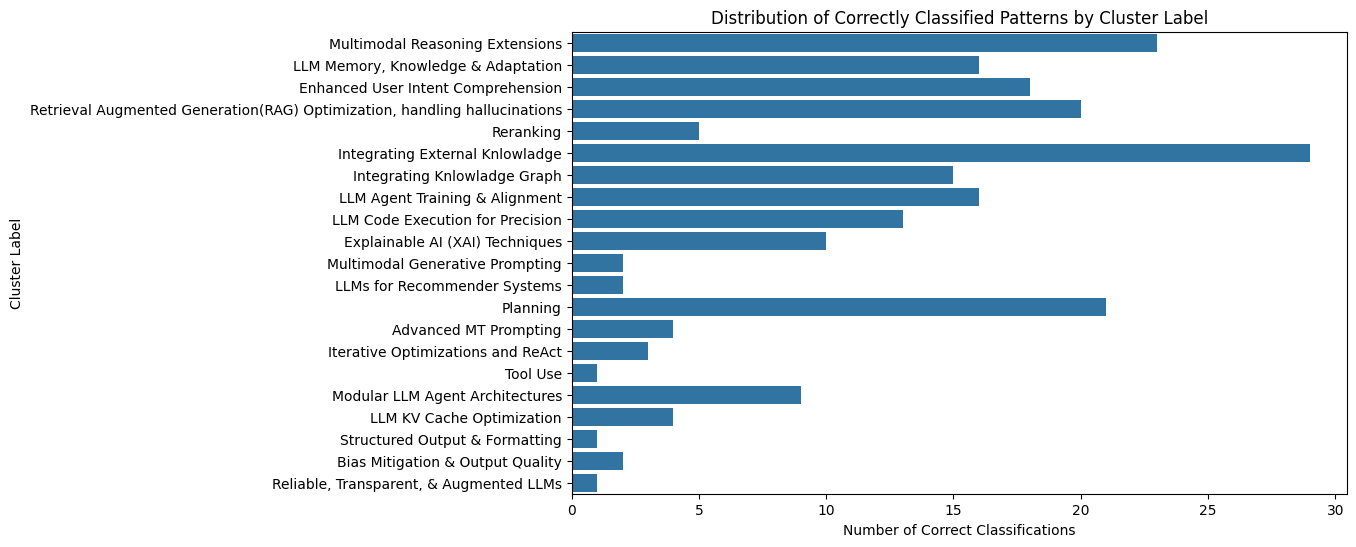

In [148]:
plt.figure(figsize=(10,6))
sns.countplot(y=[verification_result['predicted_label'] for _, verification_result in verification_results.items() if verification_result['verification_result']['is_correct']])
plt.title("Distribution of Correctly Classified Patterns by Cluster Label")
plt.ylabel("Cluster Label")
plt.xlabel("Number of Correct Classifications")
# plt.yticks(rotation=90)
plt.show()

### Html Builders